# I. IMPORT AND DOWNLOAD LIBRARIES





## 1. Download libraries

In [2]:
!pip install transformers torch torchvision scikit-learn evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00


## 2. Import libraries

In [3]:
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
import torch
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate
import torch.nn as nn

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device used: {device}")

Device used: cuda


# II. CUSTOM PYTORCH DATASET

## 1. Loading dataset

In [6]:
class Config:
  RANDOM_STATE = 42
  num_classes = 15
  num_samples_cat = 4000
  split_ratio = 0.2
  MAX_LEN = 256


cfg = Config()

In [7]:
ds = load_dataset("UniverseTBD/arxiv-abstracts-large")
ds

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/810 [00:00<?, ?B/s]

arxiv-metadata-oai-snapshot.json:   0%|          | 0.00/3.82G [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2292057 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'report-no', 'categories', 'license', 'abstract', 'versions', 'update_date', 'authors_parsed'],
        num_rows: 2292057
    })
})

In [8]:
df = ds["train"].to_pandas()
df.head()

,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed
0,0704.0001,Pavel Nadolsky,"C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-...",Calculation of prompt diphoton production cros...,"37 pages, 15 figures; published version","Phys.Rev.D76:013009,2007",10.1103/PhysRevD.76.013009,ANL-HEP-PR-07-12,hep-ph,None,A fully differential calculation in perturba...,"[{'version': 'v1', 'created': 'Mon, 2 Apr 2007...",2008-11-26,"[[Balázs, C., ], [Berger, E. L., ], [Nadolsky,..."
1,0704.0002,Louis Theran,Ileana Streinu and Louis Theran,Sparsity-certifying Graph Decompositions,To appear in Graphs and Combinatorics,None,None,None,math.CO cs.CG,http://arxiv.org/licenses/nonexclusive-distrib...,"We describe a new algorithm, the $(k,\ell)$-...","[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2008-12-13,"[[Streinu, Ileana, ], [Theran, Louis, ]]"
2,0704.0003,Hongjun Pan,Hongjun Pan,The evolution of the Earth-Moon system based o...,"23 pages, 3 figures",None,None,None,physics.gen-ph,None,The evolution of Earth-Moon system is descri...,"[{'version': 'v1', 'created': 'Sun, 1 Apr 2007...",2008-01-13,"[[Pan, Hongjun, ]]"
3,0704.0004,David Callan,David Callan,A determinant of Stirling cycle numbers counts...,11 pages,None,None,None,math.CO,None,We show that a determinant of Stirling cycle...,"[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2007-05-23,"[[Callan, David, ]]"
4,0704.0005,Alberto Torchinsky,Wael Abu-Shammala and Alberto Torchinsky,From dyadic $\Lambda_{\alpha}$ to $\Lambda_{\a...,None,"Illinois J. Math. 52 (2008) no.2, 681-689",None,None,math.CA math.FA,None,In this paper we show how to compute the $\L...,"[{'version': 'v1', 'created': 'Mon, 2 Apr 2007...",2013-10-15,"[[Abu-Shammala, Wael, ], [Torchinsky, Alberto, ]]"


In [9]:
for i in range(3):
  print(f"Example {i+1}:")
  print(ds["train"][i]["abstract"])
  print(ds["train"][i]["categories"])
  print("---" * 20)

Example 1:
  A fully differential calculation in perturbative quantum chromodynamics is
presented for the production of massive photon pairs at hadron colliders. All
next-to-leading order perturbative contributions from quark-antiquark,
gluon-(anti)quark, and gluon-gluon subprocesses are included, as well as
all-orders resummation of initial-state gluon radiation valid at
next-to-next-to-leading logarithmic accuracy. The region of phase space is
specified in which the calculation is most reliable. Good agreement is
demonstrated with data from the Fermilab Tevatron, and predictions are made for
more detailed tests with CDF and DO data. Predictions are shown for
distributions of diphoton pairs produced at the energy of the Large Hadron
Collider (LHC). Distributions of the diphoton pairs from the decay of a Higgs
boson are contrasted with those produced from QCD processes at the LHC, showing
that enhanced sensitivity to the signal can be obtained with judicious
selection of events.

hep-p

## 2. Preprocessing dataset

In [10]:
df["primary category"] = df["categories"].apply(lambda x: str(x).split(' ')[0].split('.')[0])
top_15_series = df['primary category'].value_counts().nlargest(15)
print(top_15_series)

top_15_topics = top_15_series.index.to_list()
print(f"The list of the top 15 topics: {top_15_topics}")

df_filtered = df[df['primary category'].isin(top_15_topics)]
print(f"The length of filtered dataset: {len(df_filtered)}")
df_balanced = df_filtered.groupby('primary category').sample(n=4000, random_state=42).reset_index(drop=True)
print(f"The length of balanced dataset: {len(df_balanced)}")


encoder = LabelEncoder()
df_balanced['label'] = encoder.fit_transform(df_balanced['primary category'])
print(df_balanced['label'])

primary category
math        461568
cs          431766
cond-mat    297127
astro-ph    285798
physics     163944
hep-ph      127013
hep-th      101262
quant-ph     99689
gr-qc        59456
stat         43860
eess         39346
nucl-th      32059
math-ph      30347
q-bio        25996
hep-ex       21951
Name: count, dtype: int64
The list of the top 15 topics: ['math', 'cs', 'cond-mat', 'astro-ph', 'physics', 'hep-ph', 'hep-th', 'quant-ph', 'gr-qc', 'stat', 'eess', 'nucl-th', 'math-ph', 'q-bio', 'hep-ex']
The length of filtered dataset: 2221182
The length of balanced dataset: 60000
0         0
1         0
2         0
3         0
4         0
         ..
59995    14
59996    14
59997    14
59998    14
59999    14
Name: label, Length: 60000, dtype: int64


## 3. CREATE CUSTOM PYTORCH DATASET

In [30]:
class AbstractClassificationDataset(Dataset):
  '''
  abstracts: the input abstract of the dataframe
  labels: the integer representing label
  tokenizer: AutoTokenizer()
  max_length: max length of each sentence - how many to truncate/ pad to
  '''

  def __init__(self, abstracts, labels, tokenizer, max_length = cfg.MAX_LEN):
    self.abstracts = abstracts
    self.labels = labels
    self.tokenizer = tokenizer
    self.max_length = max_length

  def __len__(self):
    '''
    return the total size of the dataset
    '''
    return len(self.abstracts)

  def __getitem__(self, idx):
    '''
    args: idx
    abstract is the df['abstract']
    label is the df['label']
    grab the specific abstract and label
    then tokenize



    return:
    {
    input_ids:
    attention_mask:
    labels:
    }
    '''

    abstract = str(self.abstracts[idx])
    label = self.labels[idx]

    encoding = self.tokenizer(
        abstract,
        add_special_tokens = True,
        max_length = self.max_length,
        padding = 'max_length',
        truncation = True,
        return_attention_mask = True,
        return_tensors = 'pt' #wrap the output into pytorch tensor
    )

    return {
        'input_ids': encoding["input_ids"].flatten(),
        'attention_mask': encoding['attention_mask'].flatten(),
        'labels': torch.tensor(label, dtype = torch.long)
    }


tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

#stratified sampling
df_train, df_temp = train_test_split(
    df_balanced,
    test_size = cfg.split_ratio,
    random_state = cfg.RANDOM_STATE,
    stratify = df_balanced['label']
)

#split df_temp in half for val and test
df_val, df_test = train_test_split(
    df_temp,
    test_size = 0.5,
    random_state = cfg.RANDOM_STATE,
    stratify = df_temp['label']
)

# Reset indices to ensure sequential access for DataLoaders
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print(f"Number of training samples: {len(df_train)}")
print(f"Number of validation samples: {len(df_val)}")
print(f"Number of testing samples: {len(df_test)}")

Number of training samples: 48000
Number of validation samples: 6000
Number of testing samples: 6000


In [31]:
train_dataset = AbstractClassificationDataset(
    abstracts = df_train['abstract'],
    labels = df_train['label'],
    tokenizer = tokenizer,
    max_length = cfg.MAX_LEN
)

test_dataset = AbstractClassificationDataset(
    abstracts = df_test['abstract'],
    labels = df_test['label'],
    tokenizer = tokenizer,
    max_length = cfg.MAX_LEN
)

val_dataset = AbstractClassificationDataset(
    abstracts = df_val['abstract'],
    labels = df_val['label'],
    tokenizer = tokenizer,
    max_length = cfg.MAX_LEN
)


train_loader = DataLoader(
    dataset = train_dataset,
    batch_size = 16,
    shuffle = True,
    num_workers = 2
)

val_loader = DataLoader(
    dataset = val_dataset,
    batch_size = 16,
    shuffle = False,
    num_workers = 2
)

test_loader = DataLoader(
    dataset = test_dataset,
    batch_size = 16,
    shuffle = False,
    num_workers = 2
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of testing batches: {len(test_loader)}")


Number of training batches: 3000
Number of validation batches: 375
Number of testing batches: 375


# III. Training Loop

In [32]:
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased',
                                                           num_labels = cfg.num_classes)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [33]:
print(model)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [36]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load('recall')

def compute_metrics(eval_pred):
  logits, labels = eval_pred
  predictions = np.argmax(logits, axis = -1)

  acc = accuracy_metric.compute(predictions = predictions, references = labels)
  f1 = f1_metric.compute(predictions = predictions, references = labels, average = "macro")
  prec = precision_metric.compute(predictions = predictions, references = labels, average = "macro")
  rec = recall_metric.compute(predictions = predictions, references = labels, average = "macro")

  return {
      'accuracy': acc['accuracy'],
      'f1_macro': f1['f1'],
      'precision': prec['precision'],
      'recall': rec['recall']

  }

In [38]:
training_args = TrainingArguments(
    output_dir='./bert-arxiv-results',
    eval_strategy="epoch",     # Evaluate after each epoch
    save_strategy="epoch",           # Save model after each epoch
    learning_rate=2e-5,              # Small lr to prevent forgetting knowledge
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,              # Train 3 epochs
    weight_decay=0.01,
    load_best_model_at_end=True,     # Automatically load best model
    metric_for_best_model="f1_macro" # Choose model based on F1 score
)

# put it all into the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,     # Dataset 80%
    eval_dataset=val_dataset,        # Dataset 10%
    compute_metrics=compute_metrics
)

#Training
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall
1,0.420511,0.749215,0.768000,0.766624,0.778322,0.768000
2,0.417297,0.706463,0.784333,0.783478,0.786134,0.784333
3,0.257861,0.771167,0.782167,0.781508,0.783173,0.782167


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=9000, training_loss=0.384705071343316, metrics={'train_runtime': 7644.8114, 'train_samples_per_second': 18.836, 'train_steps_per_second': 1.177, 'total_flos': 1.8946207162368e+16, 'train_loss': 0.384705071343316, 'epoch': 3.0})

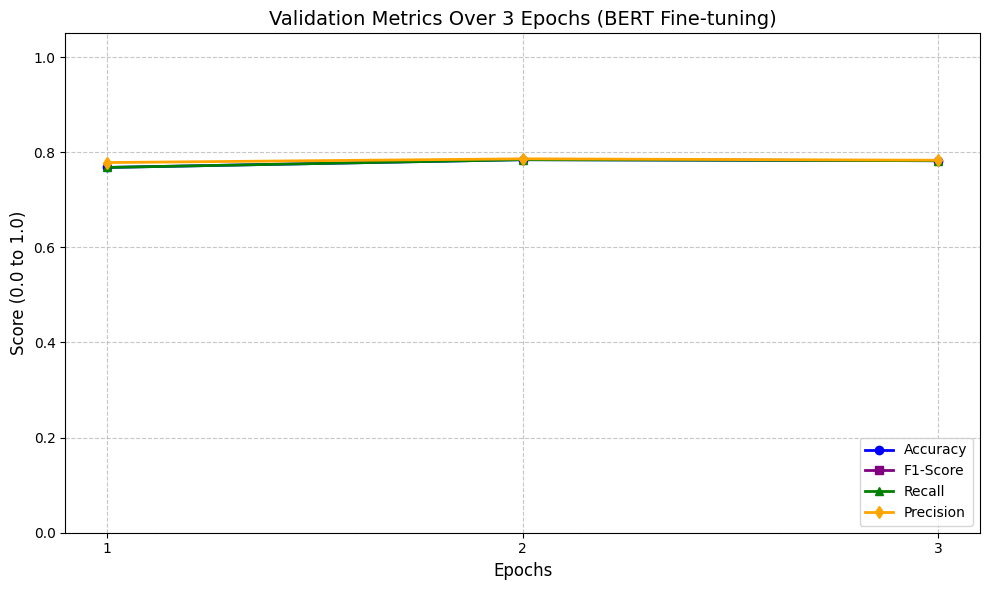

In [39]:
import matplotlib.pyplot as plt

# 1. Lấy lịch sử log từ Trainer
log_history = trainer.state.log_history

# 2. Khởi tạo mảng lưu trữ
epochs = []
eval_accuracy = []
eval_f1 = []
eval_recall = []
eval_precision = []

# 3. Duyệt qua log_history để lấy số liệu của tập Validation
for log in log_history:
    if 'eval_loss' in log and 'epoch' in log:
        epochs.append(log['epoch'])
        # Đảm bảo các key này khớp với tên bạn đã return trong compute_metrics (cộng thêm 'eval_')
        eval_accuracy.append(log.get('eval_accuracy'))
        eval_f1.append(log.get('eval_f1'))
        eval_recall.append(log.get('eval_recall'))
        eval_precision.append(log.get('eval_precision'))

# ==========================================
# VẼ BIỂU ĐỒ SO SÁNH 4 METRICS
# ==========================================
plt.figure(figsize=(10, 6))

plt.plot(epochs, eval_accuracy, label='Accuracy', color='blue', marker='o', linewidth=2)
plt.plot(epochs, eval_f1, label='F1-Score', color='purple', marker='s', linewidth=2)
plt.plot(epochs, eval_recall, label='Recall', color='green', marker='^', linewidth=2)
plt.plot(epochs, eval_precision, label='Precision', color='orange', marker='d', linewidth=2)

plt.title('Validation Metrics Over 3 Epochs (BERT Fine-tuning)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.xticks(epochs) # Ép trục X chỉ hiển thị số nguyên của epoch (1, 2, 3)
plt.ylim(0, 1.05)  # Giới hạn trục Y từ 0 đến 1
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Đang chạy dự đoán trên tập Test...



--- BÁO CÁO PHÂN LOẠI TRÊN TẬP TEST ---
              precision    recall  f1-score   support

        math       0.94      0.90      0.92       400
          cs       0.75      0.78      0.76       400
    cond-mat       0.74      0.64      0.68       400
    astro-ph       0.74      0.82      0.78       400
     physics       0.78      0.89      0.83       400
      hep-ph       0.91      0.91      0.91       400
      hep-th       0.79      0.76      0.77       400
    quant-ph       0.78      0.73      0.75       400
       gr-qc       0.79      0.70      0.74       400
        stat       0.64      0.68      0.66       400
        eess       0.88      0.85      0.87       400
     nucl-th       0.64      0.65      0.64       400
     math-ph       0.86      0.84      0.85       400
       q-bio       0.81      0.81      0.81       400
      hep-ex       0.74      0.82      0.78       400

    accuracy                           0.78      6000
   macro avg       0.79      0.78      

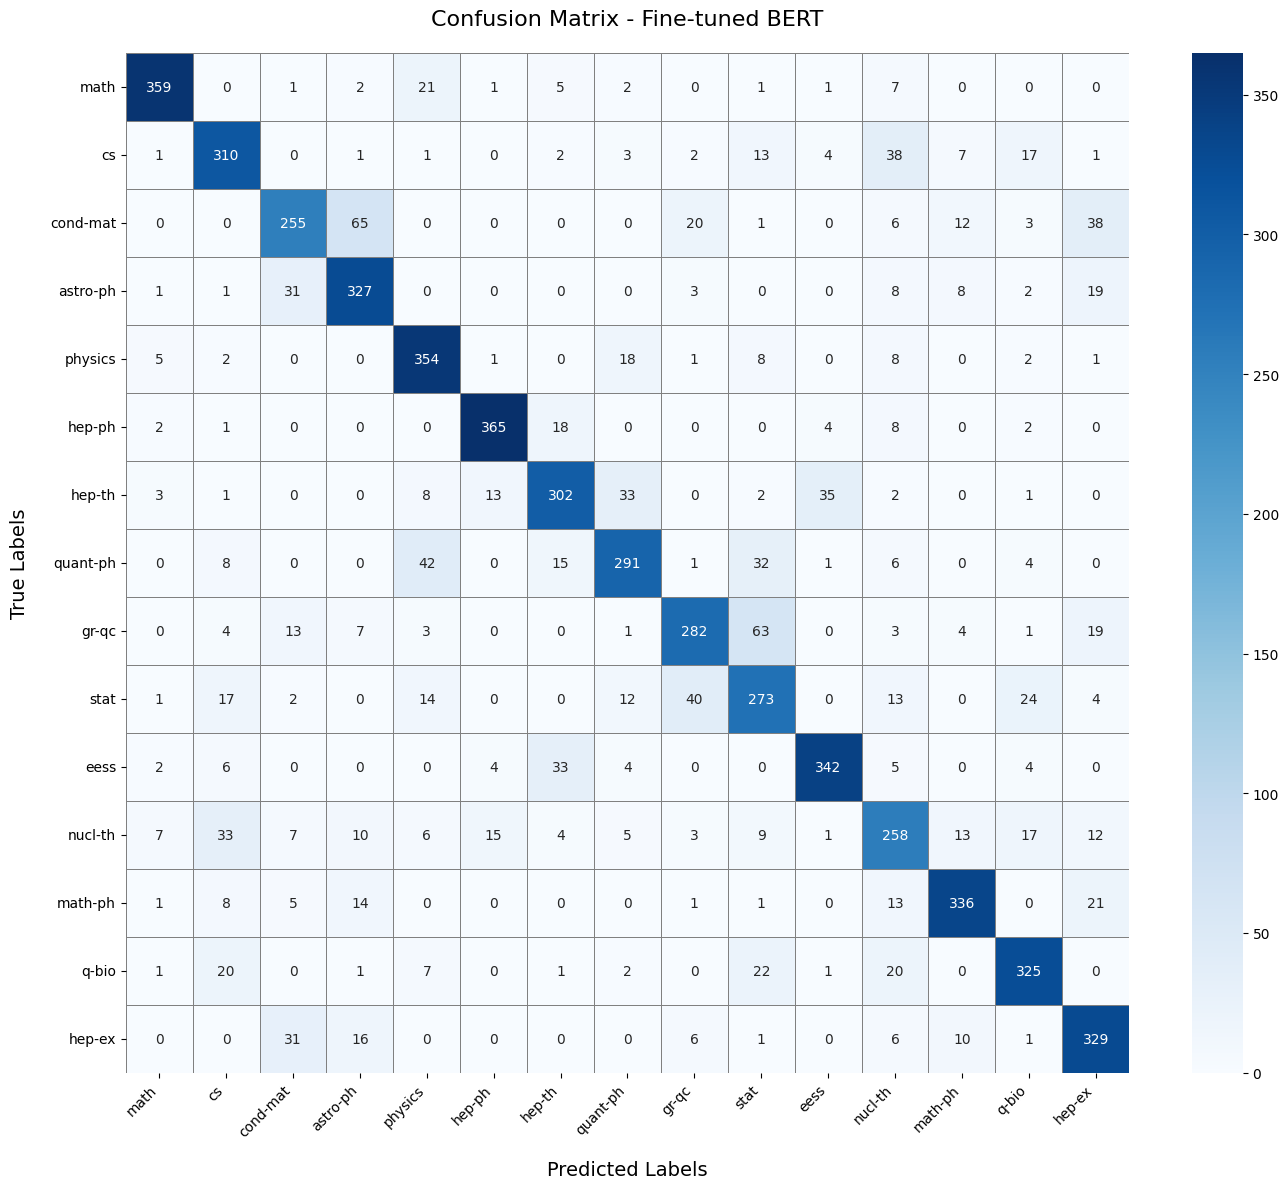

In [40]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ==========================================
# 1. INFERENCE TRÊN TẬP TEST
# ==========================================
print("Đang chạy dự đoán trên tập Test...")
predictions_output = trainer.predict(test_dataset)

# Lấy logits (dự đoán thô) và y_true (đáp án chuẩn)
logits = predictions_output.predictions
y_true = predictions_output.label_ids

# Chuyển logits thành nhãn dự đoán bằng hàm argmax
y_pred = np.argmax(logits, axis=-1)

# ==========================================
# 2. IN BÁO CÁO PHÂN LOẠI (TEXT)
# ==========================================
# Lưu ý: top_15_topics là list chứa tên 15 chủ đề bạn đã tạo ở bước xử lý Pandas
print("\n--- BÁO CÁO PHÂN LOẠI TRÊN TẬP TEST ---")
print(classification_report(y_true, y_pred, target_names=top_15_topics))

# ==========================================
# 3. VẼ CONFUSION MATRIX
# ==========================================
# Tính toán ma trận nhầm lẫn
cm = confusion_matrix(y_true, y_pred)

# Vẽ ma trận bằng Seaborn Heatmap
plt.figure(figsize=(14, 12)) # Cỡ ảnh lớn vì có tới 15 class
sns.heatmap(
    cm,
    annot=True,       # Hiển thị số lượng bên trong từng ô
    fmt='d',          # Hiển thị định dạng số nguyên (integer)
    cmap='Blues',     # Dùng dải màu xanh tương tự trong file PDF của dự án
    xticklabels=top_15_topics,
    yticklabels=top_15_topics,
    linewidths=0.5,
    linecolor='gray'
)

plt.title('Confusion Matrix - Fine-tuned BERT', fontsize=16, pad=20)
plt.xlabel('Predicted Labels', fontsize=14, labelpad=15)
plt.ylabel('True Labels', fontsize=14, labelpad=15)
plt.xticks(rotation=45, ha='right') # Xoay nhãn trục X 45 độ để không bị đè chữ
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()